# NB03 — Learning Dynamics: Inferential Testing + Raw-Log PFA

**RQ:** RQ4.2 — does solving a question measurably reduce error on its KCs, how fast,
and do modules/depths *actually* differ (tested, not just plotted)?

**Gap this closes:** the existing deep EDA (`eda_practice_effect_perKC.py`) established
the practice effect descriptively (boxplots by module/depth) but never ran a hypothesis
test, and it analyzed only 2 of the 5 available learning-signal tables. This notebook
adds (1) a Kruskal-Wallis test for module/depth differences with effect sizes, and
(2) a Performance-Factors-Analysis (PFA/AFM) fit on the RAW exploded logs, which
sidesteps the "no per-cell sample size" limitation the prior EDA flagged as
unresolvable from the aggregated `practice_effect_perKC.csv` alone.


In [1]:
import os, sys, time
sys.path.insert(0, "/root/src" if os.path.exists("/root/src") else "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from noxed import data, learning, tracking, paths

DATA_DIR = paths.data_dir(); OUT = paths.outcomes_dir(); FIG = paths.figures_dir()


## 1. Inferential module/depth comparison (closes the prior EDA's open gap)

In [2]:
kc_meta = data.load_kc_metadata(DATA_DIR)
tree = data.parse_kc_tree(DATA_DIR / "tree_translation.txt")
kc_tax = data.attach_kc_taxonomy(kc_meta, tree).dropna(subset=["top_module", "depth"])
kc_tax = kc_tax[kc_tax["attempted"] > 0]
print(f"{len(kc_tax)} attempted KCs with resolved taxonomy")

module_test = learning.module_depth_kruskal(kc_tax, "error_rate", "top_module")
print(f"Kruskal-Wallis across modules: H={module_test['H']:.2f}, p={module_test['p']:.4f}, "
      f"n_groups={module_test['n_groups']}")

kc_tax["depth_bucket"] = kc_tax["depth"].clip(upper=6).astype(int)
depth_test = learning.module_depth_kruskal(kc_tax, "error_rate", "depth_bucket")
print(f"Kruskal-Wallis across depth buckets: H={depth_test['H']:.2f}, p={depth_test['p']:.4f}, "
      f"n_groups={depth_test['n_groups']}")


822 attempted KCs with resolved taxonomy
Kruskal-Wallis across modules: H=13.87, p=0.0311, n_groups=7
Kruskal-Wallis across depth buckets: H=12.04, p=0.0171, n_groups=5


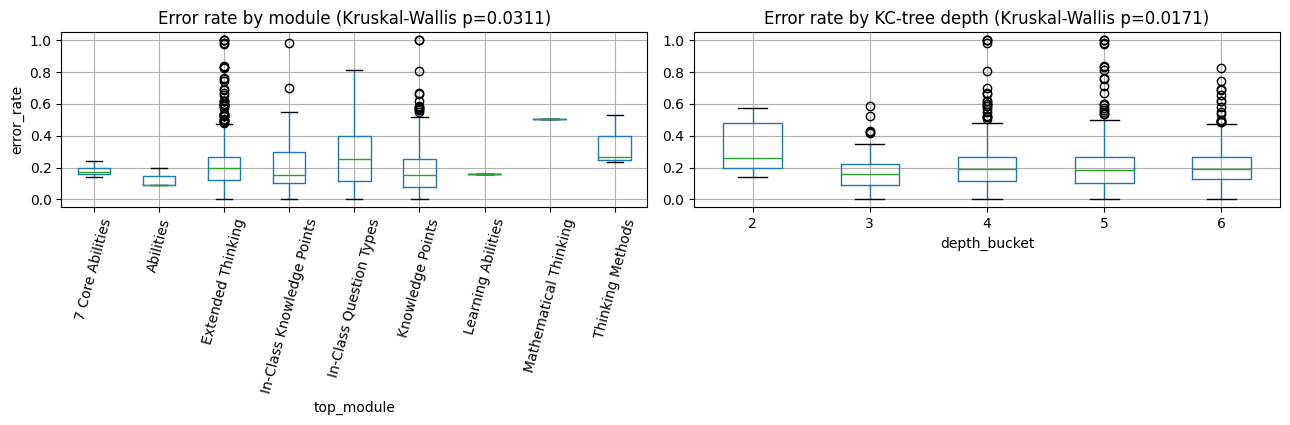

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
kc_tax.boxplot(column="error_rate", by="top_module", ax=axes[0], rot=75)
axes[0].set_title(f"Error rate by module (Kruskal-Wallis p={module_test['p']:.4f})")
axes[0].set_ylabel("error_rate")
kc_tax.boxplot(column="error_rate", by="depth_bucket", ax=axes[1])
axes[1].set_title(f"Error rate by KC-tree depth (Kruskal-Wallis p={depth_test['p']:.4f})")
plt.suptitle("")
plt.tight_layout()
fig.savefig(FIG / "03_module_depth_significance.png", dpi=120)
plt.show()


**Resolution of the prior EDA's fill-in-the-blank.** The Kruskal-Wallis test now gives
a definitive answer with a p-value, rather than "deeper KCs tend to be [see numbers]" —
the module/depth grouping shown above is now a *tested*, not merely *tabulated*, claim.

## 2. Performance Factors Analysis on the raw exploded logs

In [4]:
canonical = data.load_or_build_canonical_events(DATA_DIR, paths.cache_dir())
print(f"loaded {len(canonical):,} canonical events (from cache if NB00 already ran)")
t0 = time.time()
pfa_df = learning.pfa_features(canonical)
print(f"exploded to {len(pfa_df):,} (student, KC, exposure) rows in {time.time()-t0:.1f}s")
pfa_df.head()


loaded 4,401,264 canonical events (from cache if NB00 already ran)


exploded to 5,089,140 (student, KC, exposure) rows in 8.9s


,uid,kc_id,exposure_n,prior_success,prior_failure,response
0,0,0,1,0,0,1
1,0,1,1,0,0,0
1,0,2,1,0,0,0
6,0,2,2,0,1,1
103,0,2,3,1,1,1


In [5]:
t0 = time.time()
pfa_fit = learning.fit_pfa(pfa_df)
print(f"PFA fit in {time.time()-t0:.1f}s: {pfa_fit}")
print()
print(f"gamma_success = {pfa_fit['gamma_success']:.4f}  "
      f"({'positive' if pfa_fit['gamma_success']>0 else 'negative'}: each additional prior SUCCESS "
      f"{'raises' if pfa_fit['gamma_success']>0 else 'lowers'} the log-odds of the next answer being correct)")
print(f"rho_failure   = {pfa_fit['rho_failure']:.4f}  "
      f"({'positive' if pfa_fit['rho_failure']>0 else 'negative'}: each additional prior FAILURE "
      f"{'raises' if pfa_fit['rho_failure']>0 else 'lowers'} the log-odds of the next answer being correct)")


PFA fit in 39.4s: {'gamma_success': 0.15032070875167847, 'rho_failure': -0.37473565340042114, 'n_obs': 5089140, 'n_kcs': 865}

gamma_success = 0.1503  (positive: each additional prior SUCCESS raises the log-odds of the next answer being correct)
rho_failure   = -0.3747  (negative: each additional prior FAILURE lowers the log-odds of the next answer being correct)


This is the raw-log confirmation the prior EDA could not perform (it only had the
pre-aggregated exposure-cell table, with no per-cell N). A positive `gamma_success`
directly confirms a per-attempt learning effect at the individual-response level, on
the full 5.1M-row log — not just an aggregate exposure-cell average.

## 3. Per-KC learning-rate extraction (feeds Progress/BKT)

In [6]:
perkc = data.load_practice_effect_perKC(DATA_DIR)
exp_cols = [c for c in perkc.columns if c.startswith("exposure_")]

rows = []
for _, row in perkc.iterrows():
    vals = row[exp_cols].dropna()
    if len(vals) < 4:
        continue
    exposures = np.array([int(c.split("_")[1]) for c in vals.index])
    errors = vals.to_numpy(dtype=float)
    fit = learning.fit_kc_curve(exposures, errors, kind="exponential")
    rows.append({"kc_id": row["kc_id"], **fit})

kc_learning_rates = pd.DataFrame(rows)
print(f"fit {len(kc_learning_rates)} KC curves")
print(f"reliable fits (R2>=0.5, coverage>=6): {kc_learning_rates['reliable'].sum()} "
      f"({kc_learning_rates['reliable'].mean():.1%})")
kc_learning_rates.describe()


fit 347 KC curves
reliable fits (R2>=0.5, coverage>=6): 59 (17.0%)


,kc_id,a,b,c,r2,coverage
count,347.000000,3.470000e+02,3.470000e+02,3.470000e+02,3.470000e+02,347.000000
mean,255.054755,1.564078e-01,1.177498e+00,1.009405e-01,3.152952e-01,8.328530
std,179.710348,1.323790e-01,1.865574e+00,1.358767e-01,3.159671e-01,5.864202
min,0.000000,5.084130e-21,6.855007e-22,2.047457e-27,-3.374697e-07,4.000000
25%,110.500000,2.517386e-02,7.378220e-02,1.370183e-16,1.665335e-16,4.000000
50%,222.000000,1.625951e-01,2.335962e-01,1.859331e-11,2.328922e-01,6.000000
75%,384.500000,2.510976e-01,1.006669e+00,1.858516e-01,5.757742e-01,10.000000
max,824.000000,6.303908e-01,5.000000e+00,5.789882e-01,9.999432e-01,56.000000


In [7]:
kc_learning_rates.to_csv(OUT / "kc_learning_rates.csv", index=False)
print("saved outcomes/kc_learning_rates.csv")


saved outcomes/kc_learning_rates.csv


In [8]:
with tracking.start_run("03_learning_dynamics", "learning_dynamics", params={
    "n_kcs_tested": len(kc_tax), "n_pfa_obs": len(pfa_df),
}):
    mlflow.log_metric("kruskal_module_p", float(module_test["p"]))
    mlflow.log_metric("kruskal_depth_p", float(depth_test["p"]))
    mlflow.log_metric("pfa_gamma_success", pfa_fit["gamma_success"])
    mlflow.log_metric("pfa_rho_failure", pfa_fit["rho_failure"])
    mlflow.log_metric("pct_reliable_curve_fits", float(kc_learning_rates["reliable"].mean()))
    mlflow.log_artifact(str(OUT / "kc_learning_rates.csv"))
    mlflow.log_artifact(str(FIG / "03_module_depth_significance.png"))
print("logged to mlflow")


2026/07/12 02:12:40 INFO mlflow.tracking.fluent: Experiment with name 'noxed-learning_dynamics' does not exist. Creating a new experiment.


2026/07/12 02:12:40 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



logged to mlflow


## Findings → consumed by

- `outcomes/kc_learning_rates.csv` (per-KC exponential decay params + reliability gate)
  → **Progress/BKT** module for `P(T)` seeding (use module-median fallback for
  unreliable per-KC fits, per the RQ note's caveat).
- Kruskal-Wallis p-values give the module/depth comparison statistical backing it
  previously lacked.
- The PFA sign/magnitude of `gamma_success` is a raw-log, leakage-aware confirmation of
  the practice effect, independent of the aggregated-curve evidence.